# Challenge Validate

In [1]:
try:
    import mat73
except ImportError:
    pass

from pathlib import Path

import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

In [2]:
path = "~/jobs/deploy/decode"
path = Path(path).expanduser()
import sys

sys.path.insert(0, str(path))

In [3]:
import decode
import decode.evaluation.optimize
from decode.neuralfitter.train import setup_cfg
import decode.neuralfitter.inference.functional as infer_func
print(decode.__file__)


%config InlineBackend.figure_format='retina'

/home/riesgroup/jobs/deploy/decode/decode/__init__.py


In [4]:
path_out = "/mnt/t1ries/users/Lucas/Manuscripts/plex/raw/biplane_challenge"
path_out = Path(path_out)

In [20]:
p_decode = path_out / "MT0_N2_LD_decode_fit_dens_filtered.h5"
em = decode.EmitterSet.load(p_decode)

In [21]:
p_gt = "/home/riesgroup/decode_scratch/challenge/MT0_N2_LD/activations.csv"
em_gt, *_ = decode.io.emitter.load_challenge(p_gt)
em_gt = decode.EmitterSet(**em_gt, xy_unit="nm")

<Axes: >

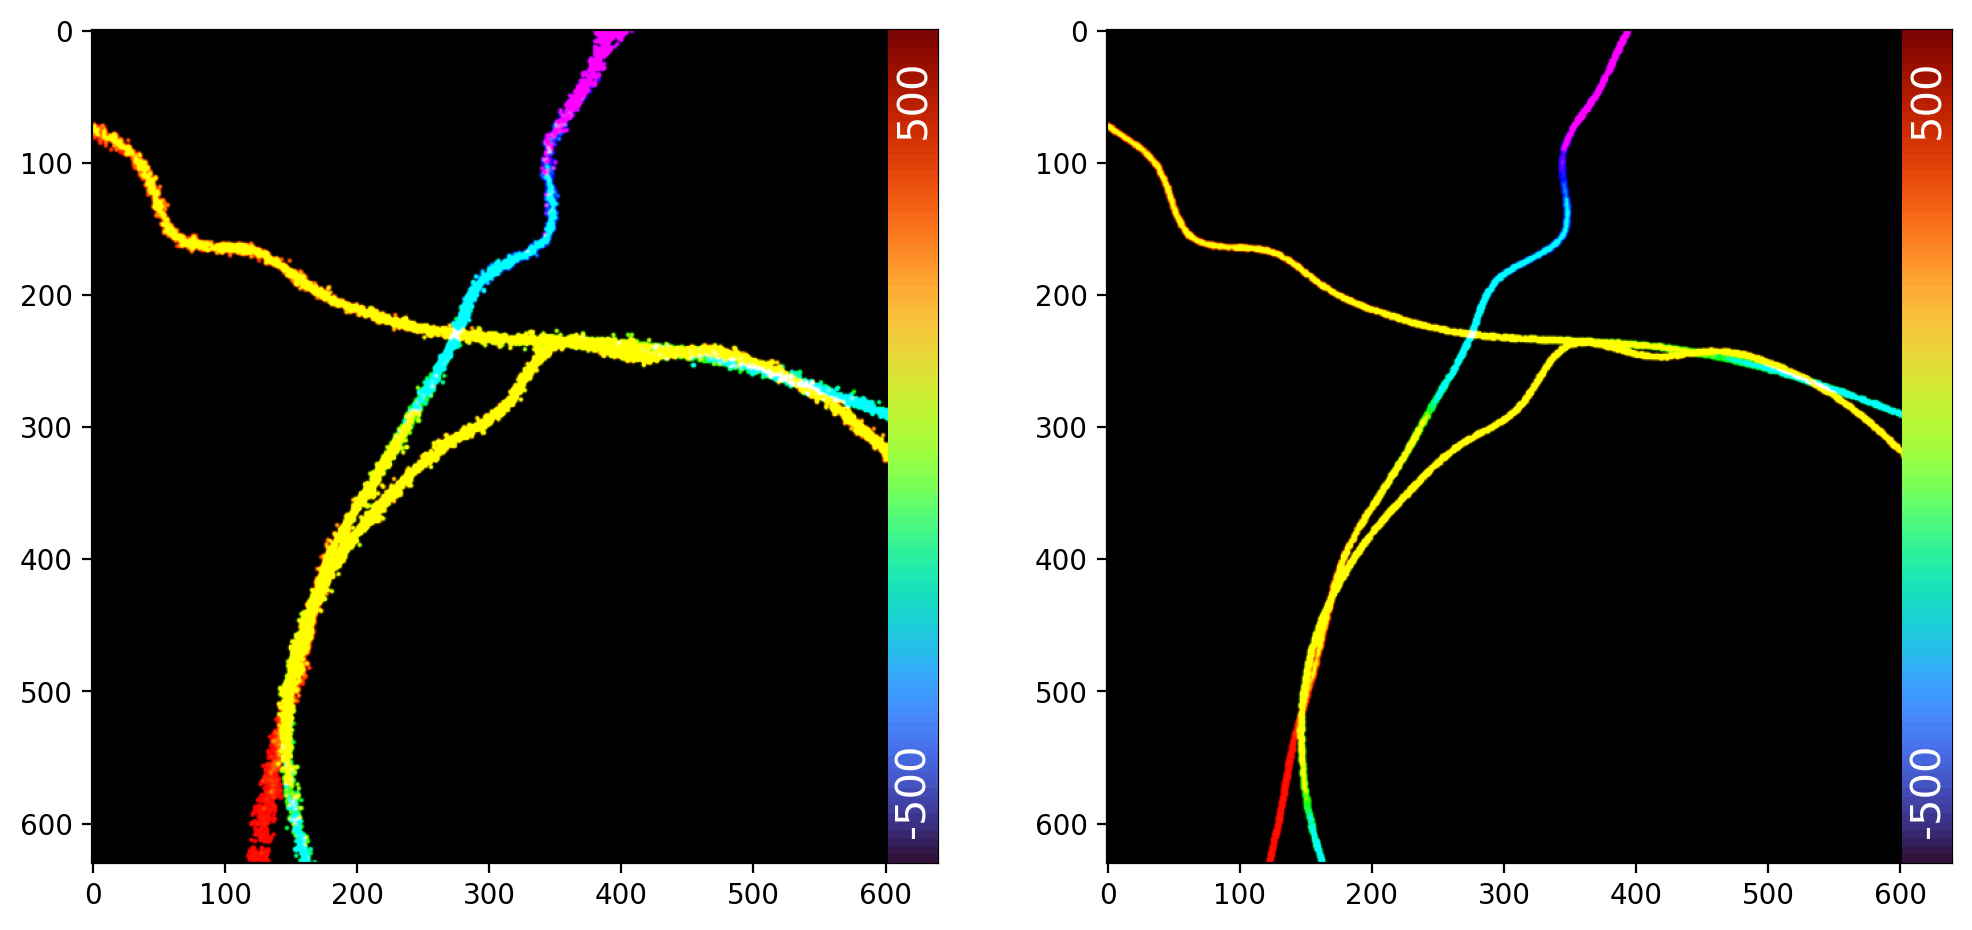

In [22]:
renderer = decode.renderer.renderer.Renderer2D(
    xextent=(0., 64*100.),
    yextent=(100., 64*100.),
    colextent=[-500,500],
    px_size=10.,
    sigma_blur=10.,
    rel_clip=0.05,
    contrast=10,
    cmap="turbo",
)

fig, axs = plt.subplots(1, 2, figsize=(12, 9))
renderer.render(em, em.xyz[:, 2], ax=axs[0])
renderer.render(em_gt, em_gt.xyz[:, 2], ax=axs[1])